# Token Code Usage Under Dataset Shift

This notebook compares tokenizer code usage between the in-distribution reference set, `imagenet`, and one or more out-of-distribution datasets. The core hypothesis is simple: if a model has a stable and expressive discrete vocabulary, its active-code set, usage distribution, and spatial deployment of codes should remain relatively consistent when the input distribution shifts.


## Experiment Setup

The heavy computation happens outside the notebook. For each model and dataset pair, the export script writes:

- `summary.json`: compact run-level statistics.
- `global_counts.npy`: total count for each code ID across the full dataset.
- `position_counts.npy`: count for each `(code_id, row, col)` token-grid location.
- `usage.csv`: one row per code with count, frequency, activity flag, and rank.

This notebook stays light: it loads those artifacts, compares `imagenet` against all available OOD datasets, and then drills down into one selected OOD dataset for distribution and positional analysis.


## Export Procedure

The counting itself is done in the model-specific export scripts, not in the notebook. The procedure is the same at a high level for both LlamaGen and VQGAN:

1. Enumerate the dataset as an image folder with one subdirectory per class.
2. Resize and center-crop each image to the tokenizer input resolution.
3. Run the tokenizer encoder on the image batch.
4. Extract the discrete token indices produced by the quantizer.
5. Reshape the flat index stream into a `16 x 16` token grid per image.
6. Aggregate counts over the full dataset.

More concretely, if `z[i, r, c]` is the discrete code ID at image `i`, row `r`, column `c`, then the exports record two levels of counting:

- Global code usage: for each code `k`, count how many times `z[i, r, c] = k` over all images and all token positions.
- Positional code usage: for each code `k` and token position `(r, c)`, count how many images satisfy `z[i, r, c] = k`.

A code is considered **active** on a dataset if its global count is strictly greater than zero. A code is **dead** on that dataset if its global count is zero. This is why active/dead is dataset-specific, even though the underlying codebook size is fixed.

The notebook does not recompute these heavy counts. It only loads the exported aggregates and derives secondary summaries such as active-code overlap, perplexity, top-k mass, and positional entropy.


## Artifact Definitions

Each run directory contains the same small set of files. Their meanings are formal and fixed:

- `summary.json`: run metadata and scalar summaries. This includes dataset name, number of images, number of classes, token-grid shape, total token count, active/dead code counts, entropy, perplexity, and top-k mass statistics.
- `global_counts.npy`: a one-dimensional array of shape `(codebook_size,)`. Entry `global_counts[k]` is the total number of times code `k` appears anywhere in the dataset.
- `position_counts.npy`: a three-dimensional array of shape `(codebook_size, H, W)`. Entry `position_counts[k, r, c]` is the number of images for which code `k` appears at token-grid location `(r, c)`.
- `usage.csv`: a tabular version of the global counts, one row per code. It stores count, empirical frequency, whether the code is active, and the rank of the code after sorting by descending count.
- `top_codes.csv`: a compact table of the most frequently used codes, extracted from the same ranking used in `usage.csv`.

The basic consistency identity for a correct export is:

- `sum(global_counts) = sum(position_counts) = n_images * H * W`

because every image contributes exactly one code to every token-grid location.

The main derived quantities used later in the notebook are:

- **Active code count**: `|{k : global_counts[k] > 0}|`.
- **Active fraction of full codebook**: active code count divided by the full codebook size.
- **Perplexity**: `exp(H(p))`, where `p(k) = global_counts[k] / sum(global_counts)`. This is the effective number of codes after accounting for frequency imbalance.
- **Top-k mass**: the fraction of all token assignments captured by the `k` most frequently used codes.
- **Positional entropy**: for each token-grid location `(r, c)`, entropy of the conditional distribution `P(code | r, c)` estimated from `position_counts[:, r, c]`.
- **Code-position map**: for a fixed code `k`, the normalized grid derived from `position_counts[k, :, :]`, showing where that code tends to appear spatially.

- **Perplexity** is the effective number of codes being used after accounting for imbalance. Higher means broader usage.
- **Top-10/100/500** mass is the fraction of all token assignments captured by the 10, 100, or 500 most-used codes. Higher means more concentration.


In [10]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('../code_usage_results')
MODEL_DIRS = {
    'LlamaGen': RESULTS_ROOT / 'llamagen',
    'VQGAN': RESULTS_ROOT / 'vqgan',
}
IN_DISTRIBUTION_DATASET = 'imagenet'
CODE_IDS_TO_VIEW = [0, 1]


In [11]:
def load_run(run_dir):
    summary = json.loads((run_dir / 'summary.json').read_text())
    global_counts = np.load(run_dir / 'global_counts.npy')
    position_counts = np.load(run_dir / 'position_counts.npy')
    usage = pd.read_csv(run_dir / 'usage.csv')
    return {
        'summary': summary,
        'global_counts': global_counts,
        'position_counts': position_counts,
        'usage': usage,
    }


def discover_datasets():
    datasets_per_model = {}
    for model, model_dir in MODEL_DIRS.items():
        datasets_per_model[model] = sorted(path.name for path in model_dir.iterdir() if path.is_dir())
    shared = sorted(set.intersection(*[set(names) for names in datasets_per_model.values()]))
    return datasets_per_model, shared


def load_runs(dataset_names):
    runs = {}
    for model, model_dir in MODEL_DIRS.items():
        runs[model] = {}
        for dataset in dataset_names:
            runs[model][dataset] = load_run(model_dir / dataset)
    return runs


def active_mask(global_counts):
    return global_counts > 0


def position_entropy(position_counts):
    totals = position_counts.sum(axis=0, keepdims=True)
    probs = np.divide(position_counts, totals, out=np.zeros_like(position_counts, dtype=np.float64), where=totals > 0)
    log_probs = np.zeros_like(probs)
    mask = probs > 0
    log_probs[mask] = np.log(probs[mask])
    return -(probs * log_probs).sum(axis=0)


def normalized_code_position_map(position_counts, code_id):
    grid = position_counts[code_id].astype(np.float64)
    total = grid.sum()
    return grid / total if total > 0 else grid


def make_summary_rows(runs, dataset_names):
    rows = []
    for model, model_runs in runs.items():
        imagenet_active = model_runs[IN_DISTRIBUTION_DATASET]['summary']['active_codes']
        imagenet_mask = active_mask(model_runs[IN_DISTRIBUTION_DATASET]['global_counts'])
        for dataset in dataset_names:
            run = model_runs[dataset]
            summary = run['summary']
            dataset_mask = active_mask(run['global_counts'])
            rows.append({
                'model': model,
                'dataset': dataset,
                'n_images': summary['n_images'],
                'active_codes': summary['active_codes'],
                'dead_codes': summary['dead_codes'],
                'active_fraction_full': summary['active_fraction_full'],
                'active_fraction_vs_imagenet': summary['active_codes'] / imagenet_active,
                'active_overlap_with_imagenet': (dataset_mask & imagenet_mask).sum() / imagenet_active,
                'perplexity': summary['perplexity'],
                'top_10_mass': summary['top_10_mass'],
                'top_100_mass': summary['top_100_mass'],
                'top_500_mass': summary['top_500_mass'],
            })
    return pd.DataFrame(rows)


datasets_per_model, shared_datasets = discover_datasets()
assert IN_DISTRIBUTION_DATASET in shared_datasets, 'ImageNet baseline results are required.'
ood_datasets = [name for name in shared_datasets if name != IN_DISTRIBUTION_DATASET]
comparison_datasets = [IN_DISTRIBUTION_DATASET] + ood_datasets
runs = load_runs(comparison_datasets)
summary_df = make_summary_rows(runs, comparison_datasets)

print('Shared datasets:', shared_datasets)
summary_df.head()


Shared datasets: ['imagenet', 'imagenet_v2']


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,imagenet,50000,16384,0,1.000000,1.0,1.0,16179.189378,0.002933,0.011967,0.045642
1,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.0,1.0,16094.903809,0.002756,0.012407,0.047786
2,VQGAN,imagenet,50000,972,15412,0.059326,1.0,1.0,910.464663,0.021549,0.164769,0.664882
3,VQGAN,imagenet_v2,10000,972,15412,0.059326,1.0,1.0,911.084478,0.021474,0.164576,0.663230


## Quick Validation

Each exported run should satisfy one invariant: the global token count must match the sum over all position-specific counts, and both must equal `n_images * H * W`.


In [12]:
validation_rows = []
for model, model_runs in runs.items():
    for dataset, run in model_runs.items():
        summary = run['summary']
        global_total = int(run['global_counts'].sum())
        position_total = int(run['position_counts'].sum())
        h, w = summary['token_grid_hw']
        expected_total = summary['n_images'] * h * w
        validation_rows.append({
            'model': model,
            'dataset': dataset,
            'global_total': global_total,
            'position_total': position_total,
            'expected_total': expected_total,
            'ok': global_total == position_total == expected_total,
        })

pd.DataFrame(validation_rows).sort_values(['dataset', 'model']).reset_index(drop=True)


,model,dataset,global_total,position_total,expected_total,ok
0,LlamaGen,imagenet,12800000,12800000,12800000,True
1,VQGAN,imagenet,12800000,12800000,12800000,True
2,LlamaGen,imagenet_v2,2560000,2560000,2560000,True
3,VQGAN,imagenet_v2,2560000,2560000,2560000,True


## Run-Level Summary Across Datasets

This table is the main compact view. `active_fraction_vs_imagenet` answers the baseline-normalized question directly: for each model, what fraction of the ImageNet active vocabulary remains active on each OOD dataset?


In [13]:
summary_df = summary_df.sort_values(['dataset', 'model']).reset_index(drop=True)
summary_df


,model,dataset,n_images,active_codes,dead_codes,active_fraction_full,active_fraction_vs_imagenet,active_overlap_with_imagenet,perplexity,top_10_mass,top_100_mass,top_500_mass
0,LlamaGen,imagenet,50000,16384,0,1.000000,1.0,1.0,16179.189378,0.002933,0.011967,0.045642
1,VQGAN,imagenet,50000,972,15412,0.059326,1.0,1.0,910.464663,0.021549,0.164769,0.664882
2,LlamaGen,imagenet_v2,10000,16384,0,1.000000,1.0,1.0,16094.903809,0.002756,0.012407,0.047786
3,VQGAN,imagenet_v2,10000,972,15412,0.059326,1.0,1.0,911.084478,0.021474,0.164576,0.663230


## Active Code Count by Dataset

The first comparison is absolute utilization: how many codes become active on each dataset for each model.


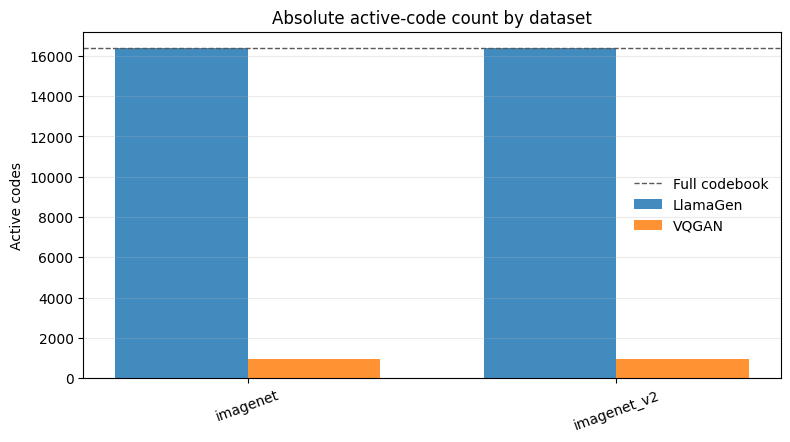

In [14]:
datasets = comparison_datasets
models = list(MODEL_DIRS)
x = np.arange(len(datasets))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.5))
for offset, model, color in [(-width / 2, 'LlamaGen', 'C0'), (width / 2, 'VQGAN', 'C1')]:
    sub = summary_df[summary_df['model'] == model].set_index('dataset').loc[datasets]
    ax.bar(x + offset, sub['active_codes'], width=width, label=model, color=color, alpha=0.85)

ax.axhline(16384, linestyle='--', color='0.35', linewidth=1, label='Full codebook')
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=20)
ax.set_ylabel('Active codes')
ax.set_title('Absolute active-code count by dataset')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
plt.show()


## ImageNet vs Each OOD Dataset

From this point on, every plot compares the fixed ImageNet baseline against each available OOD dataset. To add a new dataset, place its exported files under `code_usage_results/<model>/<dataset>/` for both models and rerun the notebook from the top.


In [ ]:
pair_df = summary_df[summary_df['dataset'].isin(comparison_datasets)].copy()
pair_df.sort_values(['dataset', 'model']).reset_index(drop=True)


## Sorted Usage Distribution

Within each model, compare the full ranked code-frequency curve on ImageNet against each OOD dataset. A steeper OOD curve means more concentrated code reuse under shift.


In [ ]:
for ood_dataset in ood_datasets:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for ax, model in zip(axes, MODEL_DIRS):
        for dataset, color in [(IN_DISTRIBUTION_DATASET, 'C2'), (ood_dataset, 'C3')]:
            counts = runs[model][dataset]['global_counts']
            freqs = np.sort(counts / counts.sum())[::-1]
            ax.plot(np.arange(1, len(freqs) + 1), freqs, label=dataset, linewidth=2, color=color)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(model)
        ax.set_xlabel('Code rank')
        ax.set_ylabel('Frequency')
        ax.grid(alpha=0.25, which='both')
        ax.legend(frameon=False)

    fig.suptitle(f'Sorted code usage: ImageNet vs {ood_dataset} (log-log)')
    plt.show()

# x -> rank after sorting by usage (1 = most used, 1000 = 1000th most used code)
# y -> the fraction of all token assignments taken by that ranked code


## Positional Entropy

For each fixed location in the `16 x 16` token grid, we look across all images and ask: “how many different codes tend to appear here, and how evenly are they used?” If many different codes appear at that location with similar frequency, entropy is high; if the same few codes appear there most of the time, entropy is low. So this plot tells us whether some spatial regions of the token grid use a richer or more restricted set of codes, and whether that pattern changes from ImageNet to each OOD dataset.


In [ ]:
for ood_dataset in ood_datasets:
    focus_datasets = [IN_DISTRIBUTION_DATASET, ood_dataset]
    entropy_grids = {
        model: {
            dataset: position_entropy(runs[model][dataset]['position_counts'])
            for dataset in focus_datasets
        }
        for model in MODEL_DIRS
    }

    fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
    vmin = min(grid.min() for model_grids in entropy_grids.values() for grid in model_grids.values())
    vmax = max(grid.max() for model_grids in entropy_grids.values() for grid in model_grids.values())

    for row, model in enumerate(MODEL_DIRS):
        for col, dataset in enumerate(focus_datasets):
            ax = axes[row, col]
            im = ax.imshow(entropy_grids[model][dataset], vmin=vmin, vmax=vmax, cmap='viridis')
            ax.set_title(f'{model} | {dataset}')
            ax.set_xticks([])
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Entropy')
    fig.suptitle(f'Per-position code entropy: ImageNet vs {ood_dataset}')
    plt.show()


## Where Individual Codes Appear

This is the direct positional view for specific code IDs. For each selected code, the heatmap shows the normalized spatial mass of that code on the token grid. If a code consistently appears in specific regions, the map will make that visible.

**Normalized position mass**: For one specific code, say code 0, we count where it appears in the `16 x 16` token grid across the whole dataset. Then we normalize those counts so the whole heatmap sums to 1. So each cell answers: “Of all times code 0 appeared, what fraction happened at this grid location?”


In [ ]:
for ood_dataset in ood_datasets:
    focus_datasets = [IN_DISTRIBUTION_DATASET, ood_dataset]
    for code_id in CODE_IDS_TO_VIEW:
        fig, axes = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
        vmax = 0.0
        maps = {}
        for model in MODEL_DIRS:
            maps[model] = {}
            for dataset in focus_datasets:
                grid = normalized_code_position_map(runs[model][dataset]['position_counts'], code_id)
                maps[model][dataset] = grid
                vmax = max(vmax, grid.max())

        for row, model in enumerate(MODEL_DIRS):
            for col, dataset in enumerate(focus_datasets):
                ax = axes[row, col]
                im = ax.imshow(maps[model][dataset], vmin=0.0, vmax=vmax, cmap='magma')
                ax.set_title(f'{model} | {dataset}')
                ax.set_xticks([])
                ax.set_yticks([])

        fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04, label='Normalized position mass')
        fig.suptitle(f'Spatial deployment of code {code_id}: ImageNet vs {ood_dataset}')
        plt.show()
